# Customer Segmentation Using K-Means Clustering

## Objective

The objective of this project is to segment customers into meaningful groups using K-Means clustering.

The segmentation will be based on customer spending, purchase frequency, average order value, and product category preferences.

The resulting customer segments will then be analyzed in business terms and used to develop targeted marketing recommendations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 1. Creating a Synthetic Customer Dataset

A synthetic customer dataset was created to represent different types of customers based on their spending behavior, purchase frequency, average order value, and product category preferences.

In [2]:
np.random.seed(42)

n_customers = 400

In [3]:
customer_ids = [
    f"CUST_{i:04d}" for i in range(1, n_customers + 1)
]

customer_ids[:10]

['CUST_0001',
 'CUST_0002',
 'CUST_0003',
 'CUST_0004',
 'CUST_0005',
 'CUST_0006',
 'CUST_0007',
 'CUST_0008',
 'CUST_0009',
 'CUST_0010']

In [4]:
data = {
    "Customer_ID": customer_ids,

    "Annual_Spend": np.random.normal(
        1000, 400, n_customers
    ),

    "Purchase_Frequency": np.random.normal(
        12, 5, n_customers
    ),

    "Average_Order_Value": np.random.normal(
        80, 25, n_customers
    ),

    "Electronics_Preference": np.random.uniform(
        0, 100, n_customers
    ),

    "Clothing_Preference": np.random.uniform(
        0, 100, n_customers
    ),

    "Beauty_Preference": np.random.uniform(
        0, 100, n_customers
    ),

    "Home_Preference": np.random.uniform(
        0, 100, n_customers
    )
}

In [5]:
df = pd.DataFrame(data)

df.head()

,Customer_ID,Annual_Spend,Purchase_Frequency,Average_Order_Value,Electronics_Preference,Clothing_Preference,Beauty_Preference,Home_Preference
0,CUST_0001,1198.685661,4.027862,103.457095,4.341253,32.819275,59.366079,81.112377
1,CUST_0002,944.694280,9.003125,67.098882,63.315138,43.401937,1.013118,63.595471
2,CUST_0003,1259.075415,12.026218,82.403019,95.140334,8.860043,63.609605,38.816571
3,CUST_0004,1609.211943,12.234903,68.443118,60.161182,22.061195,91.328695,67.413030
4,CUST_0005,906.338650,9.749673,69.137594,81.918886,59.822529,61.257347,25.990498


## 2. Exploring the Dataset

In [6]:
df.shape

(400, 8)

In [7]:
df.columns

Index(['Customer_ID', 'Annual_Spend', 'Purchase_Frequency',
       'Average_Order_Value', 'Electronics_Preference', 'Clothing_Preference',
       'Beauty_Preference', 'Home_Preference'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             400 non-null    object 
 1   Annual_Spend            400 non-null    float64
 2   Purchase_Frequency      400 non-null    float64
 3   Average_Order_Value     400 non-null    float64
 4   Electronics_Preference  400 non-null    float64
 5   Clothing_Preference     400 non-null    float64
 6   Beauty_Preference       400 non-null    float64
 7   Home_Preference         400 non-null    float64
dtypes: float64(7), object(1)
memory usage: 25.1+ KB


In [9]:
df.isnull().sum()

Customer_ID               0
Annual_Spend              0
Purchase_Frequency        0
Average_Order_Value       0
Electronics_Preference    0
Clothing_Preference       0
Beauty_Preference         0
Home_Preference           0
dtype: int64

In [10]:
features = [
    "Annual_Spend",
    "Purchase_Frequency",
    "Average_Order_Value",
    "Electronics_Preference",
    "Clothing_Preference",
    "Beauty_Preference",
    "Home_Preference"
]

X = df[features]

X.head()

,Annual_Spend,Purchase_Frequency,Average_Order_Value,Electronics_Preference,Clothing_Preference,Beauty_Preference,Home_Preference
0,1198.685661,4.027862,103.457095,4.341253,32.819275,59.366079,81.112377
1,944.694280,9.003125,67.098882,63.315138,43.401937,1.013118,63.595471
2,1259.075415,12.026218,82.403019,95.140334,8.860043,63.609605,38.816571
3,1609.211943,12.234903,68.443118,60.161182,22.061195,91.328695,67.413030
4,906.338650,9.749673,69.137594,81.918886,59.822529,61.257347,25.990498


### Feature Scaling

Since K-Means is a distance-based algorithm, the features are standardized before clustering. This prevents variables with larger numerical ranges, such as annual spending, from dominating the distance calculations.

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
X_scaled[:5]

array([[ 0.49438415, -1.54759893,  0.8143944 , -1.58831106, -0.5858719 ,
         0.34610444,  1.03565893],
       [-0.16767004, -0.55797181, -0.65263895,  0.4554439 , -0.21789667,
        -1.67212947,  0.43523449],
       [ 0.65179615,  0.04335023, -0.03512565,  1.55835419, -1.41897086,
         0.4928738 , -0.41410825],
       [ 1.56446237,  0.08485955, -0.59839979,  0.34614277, -0.95994671,
         1.4515845 ,  0.5660884 ],
       [-0.26764786, -0.40947637, -0.57037805,  1.10016154,  0.35307232,
         0.41151707, -0.85374567]])

## 3. Choosing the Number of Clusters Using the Elbow Method

The Elbow Method is used to determine a suitable number of clusters for the K-Means algorithm. Different values of K are tested and the inertia for each value is recorded.

In [13]:
inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

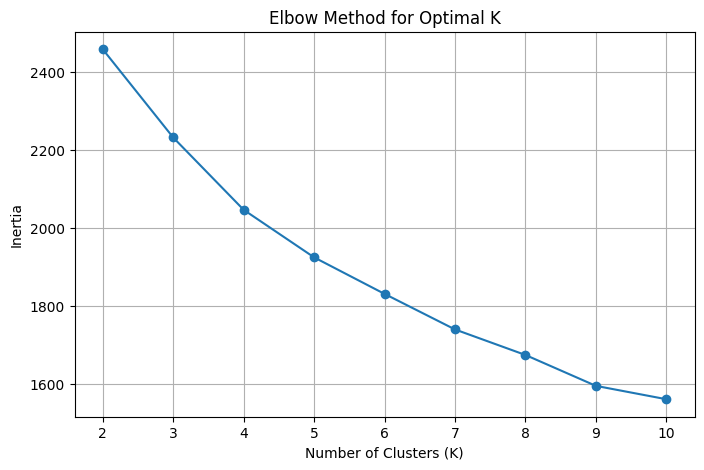

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(K)
plt.grid(True)

plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

### Selecting K

Based on the Elbow Method, K=4 was selected because the decrease in inertia becomes considerably smaller after four clusters. Therefore, four clusters provide a reasonable balance between reducing within-cluster variation and avoiding unnecessary complexity.

## 4. Applying K-Means Clustering

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [16]:
df.head()

,Customer_ID,Annual_Spend,Purchase_Frequency,Average_Order_Value,Electronics_Preference,Clothing_Preference,Beauty_Preference,Home_Preference,Cluster
0,CUST_0001,1198.685661,4.027862,103.457095,4.341253,32.819275,59.366079,81.112377,1
1,CUST_0002,944.694280,9.003125,67.098882,63.315138,43.401937,1.013118,63.595471,1
2,CUST_0003,1259.075415,12.026218,82.403019,95.140334,8.860043,63.609605,38.816571,3
3,CUST_0004,1609.211943,12.234903,68.443118,60.161182,22.061195,91.328695,67.413030,3
4,CUST_0005,906.338650,9.749673,69.137594,81.918886,59.822529,61.257347,25.990498,2


In [17]:
df["Cluster"].value_counts().sort_index()

Cluster
0    102
1    106
2     87
3    105
Name: count, dtype: int64

In [18]:
cluster_profile = df.groupby("Cluster")[features].mean()

cluster_profile

,Annual_Spend,Purchase_Frequency,Average_Order_Value,Electronics_Preference,Clothing_Preference,Beauty_Preference,Home_Preference
Cluster,,,,,,,
0,756.824734,14.299186,84.108697,40.798336,49.832309,69.879512,29.026435
1,1099.468487,11.146302,77.417198,23.359091,43.953573,24.939045,59.144006
2,1240.282419,8.515027,78.494297,65.384785,77.477230,48.852880,41.396383
3,971.080236,12.785518,92.334366,73.745070,32.237068,54.497441,71.692321


## 5. Visualizing the Customer Clusters

Principal Component Analysis (PCA) is used to reduce the seven-dimensional feature space to two dimensions. This allows the customer clusters to be visualized on a two-dimensional scatter plot.

In [19]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [20]:
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

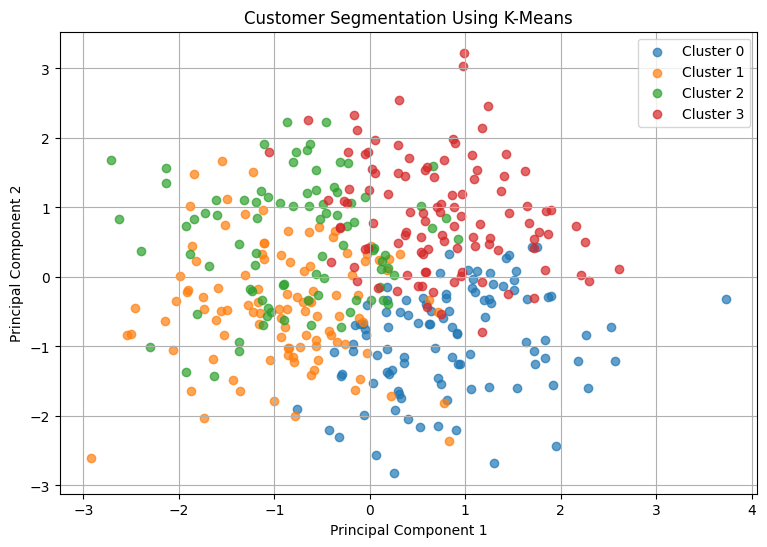

In [27]:
plt.figure(figsize=(9, 6))

for cluster in sorted(df["Cluster"].unique()):

    cluster_data = df[df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Customer Segmentation Using K-Means")

plt.legend()
plt.grid(True)

plt.savefig("customer_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
df.groupby("Cluster")[features].mean().round(2)

,Annual_Spend,Purchase_Frequency,Average_Order_Value,Electronics_Preference,Clothing_Preference,Beauty_Preference,Home_Preference
Cluster,,,,,,,
0,756.82,14.30,84.11,40.80,49.83,69.88,29.03
1,1099.47,11.15,77.42,23.36,43.95,24.94,59.14
2,1240.28,8.52,78.49,65.38,77.48,48.85,41.40
3,971.08,12.79,92.33,73.75,32.24,54.50,71.69


## 6. Customer Segment Descriptions

Cluster 0 — Beauty Buyers
These customers buy fairly often and have a strong interest in beauty products.

Cluster 1 — Home & Clothing Buyers
These customers have a good spending level and prefer home and clothing products.

Cluster 2 — High-Spending Customers
These customers spend the most, but they do not buy very often. They are valuable customers.

Cluster 3 — Electronics Buyers
These customers have high order values and a strong interest in electronics. They are also fairly active buyers.

## 7. Marketing Recommendations

Cluster 0: Offer beauty discounts, new-product deals, and beauty bundles.

Cluster 1: Promote home and clothing products with personalized offers.

Cluster 2: Give VIP rewards, premium offers, and special discounts to encourage more frequent purchases.

Cluster 3: Recommend electronics, upgrades, and product bundles.

## 8. Conclusion

K-Means clustering was used to segment customers based on their spending behavior, purchase frequency, average order value, and product category preferences.

The Elbow Method was used to determine an appropriate number of clusters, after which the customer data was standardized and K-Means clustering was applied.

The resulting clusters were visualized using PCA and analyzed according to their customer behavior and category preferences.

Each segment represents a different type of customer and can be targeted using a different marketing strategy. This demonstrates how customer segmentation can help businesses develop more personalized and effective marketing campaigns.